In [1]:
!pip install kaggle

In [2]:
# configuring the path of Kaggle.json file
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


Importing Face Mask Dataset

In [3]:
# API to fetch the dataset from Kaggle
!kaggle datasets download -d omkargurav/face-mask-dataset

Dataset URL: https://www.kaggle.com/datasets/omkargurav/face-mask-dataset
License(s): unknown
100% 163M/163M [00:01<00:00, 131MB/s]



In [4]:
# extracting the compessed Dataset
from zipfile import ZipFile
dataset = '/content/face-mask-dataset.zip'

with ZipFile(dataset,'r') as zip:
  zip.extractall()
  print('The dataset is extracted')

The dataset is extracted


In [5]:
!ls

data  face-mask-dataset.zip  sample_data


**Importing the Dependencies**

In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
from google.colab.patches import cv2_imshow
from PIL import Image
from sklearn.model_selection import train_test_split

In [7]:
with_mask_files = os.listdir('/content/data/with_mask')
print(with_mask_files[0:5])
print(with_mask_files[-5:])

['with_mask_1694.jpg', 'with_mask_1648.jpg', 'with_mask_143.jpg', 'with_mask_1806.jpg', 'with_mask_1874.jpg']
['with_mask_71.jpg', 'with_mask_1778.jpg', 'with_mask_2344.jpg', 'with_mask_3063.jpg', 'with_mask_739.jpg']


In [8]:
without_mask_files = os.listdir('/content/data/without_mask')
print(without_mask_files[0:5])
print(without_mask_files[-5:])

['without_mask_3270.jpg', 'without_mask_724.jpg', 'without_mask_3326.jpg', 'without_mask_1685.jpg', 'without_mask_1185.jpg']
['without_mask_997.jpg', 'without_mask_1529.jpg', 'without_mask_3658.jpg', 'without_mask_143.jpg', 'without_mask_3641.jpg']


In [9]:
print('Number of with mask images:', len(with_mask_files))
print('Number of without mask images:', len(without_mask_files))

Number of with mask images: 3725
Number of without mask images: 3828


**Creating Labels for the two class of Images**

with mask  -->  1

without mask  -->  0

In [10]:
# create the labels

with_mask_labels = [1]*3725

without_mask_labels = [0]*3828

In [11]:
print(with_mask_labels[0:5])

print(without_mask_labels[0:5])

[1, 1, 1, 1, 1]
[0, 0, 0, 0, 0]


In [12]:
print(len(with_mask_labels))
print(len(without_mask_labels))

3725
3828


In [13]:
labels = with_mask_labels + without_mask_labels

print(len(labels))
print(labels[0:5])
print(labels[-5:])

7553
[1, 1, 1, 1, 1]
[0, 0, 0, 0, 0]


**Displaying the Images**

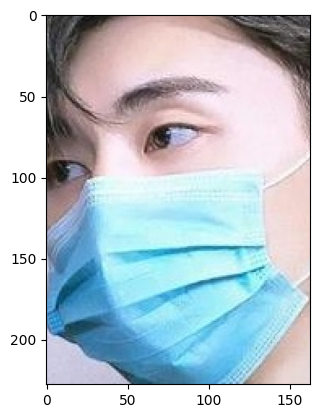

In [14]:
# displaying with mask image
img = mpimg.imread('/content/data/with_mask/with_mask_1545.jpg')
imgplot = plt.imshow(img)
plt.show()

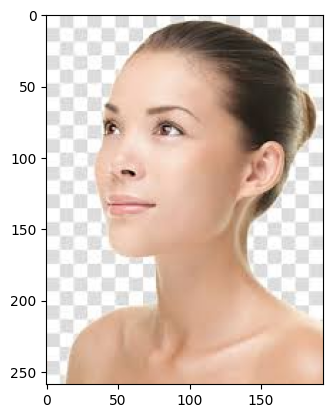

In [15]:
# displaying without mask image
img = mpimg.imread('/content/data/without_mask/without_mask_2925.jpg')
imgplot = plt.imshow(img)
plt.show()

**Image Processing**

1. Resize the Images

2. Convert the images to numpy arrays

In [16]:
# convert images to numpy arrays+

with_mask_path = '/content/data/with_mask/'

data = []

for img_file in with_mask_files:

  image = Image.open(with_mask_path + img_file)
  image = image.resize((128,128))
  image = image.convert('RGB')
  image = np.array(image)
  data.append(image)



without_mask_path = '/content/data/without_mask/'


for img_file in without_mask_files:

  image = Image.open(without_mask_path + img_file)
  image = image.resize((128,128))
  image = image.convert('RGB')
  image = np.array(image)
  data.append(image)

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [17]:
type(data)

list

In [18]:
len(data)

7553

array([[[ 27,  28,  49],
        [ 25,  26,  47],
        [ 30,  31,  52],
        ...,
        [ 61,  69, 117],
        [ 69,  78, 135],
        [ 72,  81, 146]],

       [[ 26,  27,  48],
        [ 27,  28,  49],
        [ 29,  30,  51],
        ...,
        [ 55,  62, 100],
        [ 57,  65, 112],
        [ 65,  75, 128]],

       [[ 27,  28,  49],
        [ 27,  28,  49],
        [ 25,  26,  47],
        ...,
        [ 44,  49,  77],
        [ 47,  53,  87],
        [ 49,  55,  93]],

       ...,

       [[ 21,  23,  36],
        [ 21,  23,  36],
        [ 23,  25,  39],
        ...,
        [ 65,  72, 122],
        [ 54,  68, 129],
        [ 65,  86, 151]],

       [[ 19,  21,  34],
        [ 19,  21,  34],
        [ 22,  24,  37],
        ...,
        [116, 130, 188],
        [ 80, 100, 170],
        [ 68,  94, 167]],

       [[ 19,  21,  34],
        [ 17,  19,  32],
        [ 20,  22,  35],
        ...,
        [151, 172, 233],
        [139, 167, 237],
        [104, 137, 211]]], dtype=uint8)
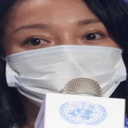

In [19]:
data[0]

In [20]:
type(data[0])

numpy.ndarray

In [21]:
data[0].shape

(128, 128, 3)

In [22]:
# converting image list and label list to numpy arrays

X = np.array(data)
Y = np.array(labels)

In [23]:
type(X)

numpy.ndarray

In [24]:
type(Y)

numpy.ndarray

In [25]:
print(X.shape)
print(Y.shape)

(7553, 128, 128, 3)
(7553,)


In [26]:
print(Y)

[1 1 1 ... 0 0 0]


**Train Test Split**

In [27]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

In [28]:
print(X.shape, X_train.shape, X_test.shape)

(7553, 128, 128, 3) (6042, 128, 128, 3) (1511, 128, 128, 3)


In [29]:
# scaling the data

X_train_scaled = X_train/255

X_test_scaled = X_test/255

array([[[ 93,  95,  72],
        [ 98,  98,  77],
        [ 93,  93,  73],
        ...,
        [204, 211, 199],
        [209, 213, 200],
        [212, 216, 204]],

       [[ 90,  87,  58],
        [ 89,  86,  55],
        [ 84,  81,  49],
        ...,
        [207, 216, 210],
        [208, 217, 209],
        [210, 219, 210]],

       [[ 87,  84,  57],
        [ 84,  78,  49],
        [ 77,  73,  38],
        ...,
        [210, 220, 214],
        [208, 218, 212],
        [209, 219, 210]],

       ...,

       [[237, 189, 112],
        [222, 167,  92],
        [226, 172,  96],
        ...,
        [ 23,  22,  17],
        [ 43,  36,  32],
        [ 46,  38,  28]],

       [[238, 195, 118],
        [222, 166,  90],
        [229, 176,  98],
        ...,
        [ 34,  33,  28],
        [ 35,  29,  23],
        [ 38,  31,  25]],

       [[237, 195, 117],
        [217, 159,  84],
        [230, 176, 100],
        ...,
        [ 28,  27,  23],
        [ 40,  36,  31],
        [ 44,  39,  33]]], dtype=uint8)
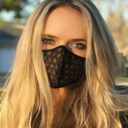

In [30]:
X_train[0]

In [31]:
X_train_scaled[0]

array([[[0.36470588, 0.37254902, 0.28235294],
        [0.38431373, 0.38431373, 0.30196078],
        [0.36470588, 0.36470588, 0.28627451],
        ...,
        [0.8       , 0.82745098, 0.78039216],
        [0.81960784, 0.83529412, 0.78431373],
        [0.83137255, 0.84705882, 0.8       ]],

       [[0.35294118, 0.34117647, 0.22745098],
        [0.34901961, 0.3372549 , 0.21568627],
        [0.32941176, 0.31764706, 0.19215686],
        ...,
        [0.81176471, 0.84705882, 0.82352941],
        [0.81568627, 0.85098039, 0.81960784],
        [0.82352941, 0.85882353, 0.82352941]],

       [[0.34117647, 0.32941176, 0.22352941],
        [0.32941176, 0.30588235, 0.19215686],
        [0.30196078, 0.28627451, 0.14901961],
        ...,
        [0.82352941, 0.8627451 , 0.83921569],
        [0.81568627, 0.85490196, 0.83137255],
        [0.81960784, 0.85882353, 0.82352941]],

       ...,

       [[0.92941176, 0.74117647, 0.43921569],
        [0.87058824, 0.65490196, 0.36078431],
        [0.88627451, 0

**Building a Convolutional Neural Networks (CNN)**

In [32]:
import tensorflow as tf
from tensorflow import keras

In [33]:
num_of_classes = 2

model = keras.Sequential()

model.add(keras.layers.Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=(128,128,3)))
model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))


model.add(keras.layers.Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))

model.add(keras.layers.Flatten())

model.add(keras.layers.Dense(128, activation='relu'))
model.add(keras.layers.Dropout(0.5))

model.add(keras.layers.Dense(64, activation='relu'))
model.add(keras.layers.Dropout(0.5))


model.add(keras.layers.Dense(num_of_classes, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [34]:
# compile the neural network
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['acc'])

In [35]:
# training the neural network
history = model.fit(X_train_scaled, Y_train, validation_split=0.1, epochs=5)

Epoch 1/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 14s 46ms/step - acc: 0.8201 - loss: 0.4285 - val_acc: 0.8545 - val_loss: 0.3343
Epoch 2/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - acc: 0.8965 - loss: 0.2662 - val_acc: 0.8926 - val_loss: 0.2672
Epoch 3/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - acc: 0.9136 - loss: 0.2124 - val_acc: 0.8975 - val_loss: 0.2649
Epoch 4/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - acc: 0.9180 - loss: 0.2132 - val_acc: 0.9174 - val_loss: 0.2312
Epoch 5/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - acc: 0.9380 - loss: 0.1623 - val_acc: 0.9355 - val_loss: 0.2282


**Model Evaluation**

In [36]:
loss, accuracy = model.evaluate(X_test_scaled, Y_test)
print('Test Accuracy =', accuracy)

48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - acc: 0.9199 - loss: 0.2055
Test Accuracy = 0.9199205636978149


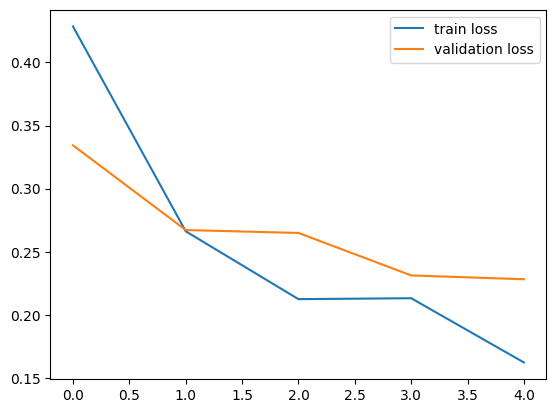

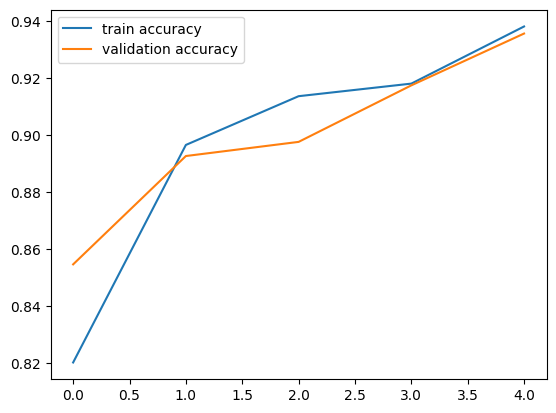

In [37]:
h = history

# plot the loss value
plt.plot(h.history['loss'], label='train loss')
plt.plot(h.history['val_loss'], label='validation loss')
plt.legend()
plt.show()

# plot the accuracy value
plt.plot(h.history['acc'], label='train accuracy')
plt.plot(h.history['val_acc'], label='validation accuracy')
plt.legend()
plt.show()

**Predictive System**

Path of the image to be predicted: /content/a-darkhoodied-masked-man-with-piercing-blue-eyes-looks-straight-into-the-camera-photo.jpeg


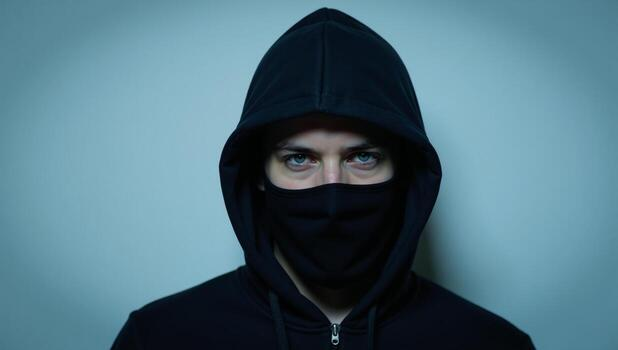

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 627ms/step
[[0.1191195 0.9820493]]
1
The person in the image is wearing a mask


In [39]:
input_image_path = input('Path of the image to be predicted: ')

input_image = cv2.imread(input_image_path)

cv2_imshow(input_image)

input_image_resized = cv2.resize(input_image, (128,128))

input_image_scaled = input_image_resized/255

input_image_reshaped = np.reshape(input_image_scaled, [1,128,128,3])

input_prediction = model.predict(input_image_reshaped)

print(input_prediction)


input_pred_label = np.argmax(input_prediction)

print(input_pred_label)


if input_pred_label == 1:

  print('The person in the image is wearing a mask')

else:

  print('The person in the image is not wearing a mask')

Path of the image to be predicted: /content/51hynM-m1ZL._AC_UF1000,1000_QL80_.jpg


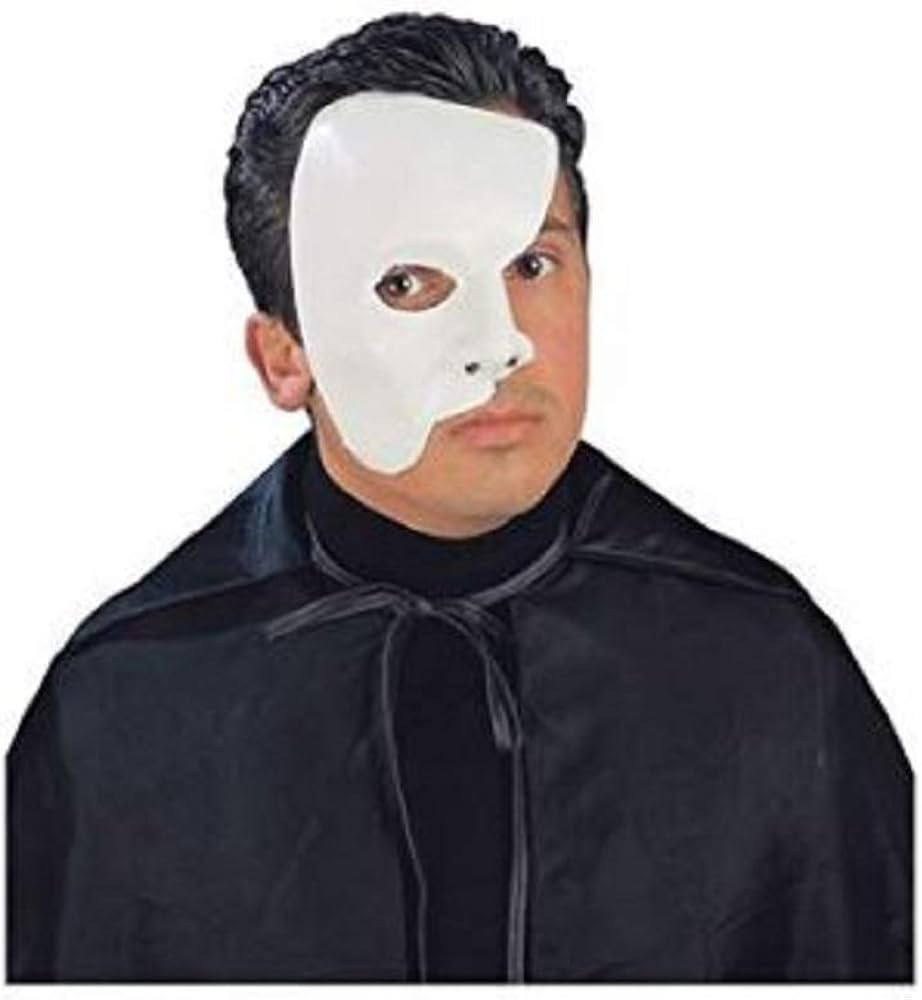

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
[[0.527745  0.5949487]]
1
The person in the image is wearing a mask


In [42]:
input_image_path = input('Path of the image to be predicted: ')

input_image = cv2.imread(input_image_path)

cv2_imshow(input_image)

input_image_resized = cv2.resize(input_image, (128,128))

input_image_scaled = input_image_resized/255

input_image_reshaped = np.reshape(input_image_scaled, [1,128,128,3])

input_prediction = model.predict(input_image_reshaped)

print(input_prediction)


input_pred_label = np.argmax(input_prediction)

print(input_pred_label)


if input_pred_label == 1:

  print('The person in the image is wearing a mask')

else:

  print('The person in the image is not wearing a mask')

In [43]:
# Save the trained model
model.save("face_mask_detector.keras")

print("Model Saved Successfully!")

Model Saved Successfully!


In [44]:
from google.colab import files

files.download("face_mask_detector.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>